# DÃ©bruitage d'images par Auto-encodeurs

### Import des modules nÃ©cessaires

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from keras import backend as K
print("Backend : ",K.backend())
from keras import layers
from keras.datasets import mnist
from keras.models import Model
import cv2
import tensorflow as tf

Backend :  tensorflow


### Quelques fonctions utiles...

In [98]:
def preprocess(array,patch_size=28):
    """Normalizes the supplied array and reshapes it."""
    array = array.astype("float32") / 255.0
    array = np.reshape(array, (len(array), patch_size, patch_size, 1))
    return array

In [99]:
def noise(array, noise_factor):
    """Adds random noise to each image in the supplied array."""
    noisy_array = array + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=array.shape
    )
    return np.clip(noisy_array, 0.0, 1.0)

In [100]:
def display(array1, array2, nb):
    """Displays nb random images from each array."""
    indices = np.random.randint(len(array1), size=nb)
    images1 = array1[indices, :]
    images2 = array2[indices, :]
    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, nb, i + 1)
        plt.imshow(image1.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax = plt.subplot(2, nb, i + 1 + nb)
        plt.imshow(image2.reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

In [101]:
def show_learning_curves(history):
    history_dict = history.history
    loss_values = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    epochs = range(1, len(history_dict['loss']) + 1)
    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.plot(epochs, loss_values, color='b', label='Training loss')
    ax1.plot(epochs, val_loss_values, color='g', label='Validation loss')
    ax1.tick_params(axis='y')

    plt.legend()
    plt.legend(loc=1)
    plt.show()

## 1 - PrÃ©paration des donnÃ©es

Chargement des images de la base MNIST (les Ã©tiquettes de classes ne sont pas utilisÃ©es ici)

In [57]:
(train_data, _), (test_data, _) = mnist.load_data()
print("Dimension du tenseur d'apprentissage MNIST :",train_data.shape)
print("Dimension du tenseur de test MNIST :",train_data.shape)

Dimension du tenseur d'apprentissage MNIST : (60000, 28, 28)
Dimension du tenseur de test MNIST : (60000, 28, 28)


Normalisation des images et mise en conformitÃ© des tenseurs

In [58]:
train_data = preprocess(train_data)
test_data = preprocess(test_data)
print("Dimension du tenseur d'apprentissage MNIST :",train_data.shape)
print("Dimension du tenseur de test MNIST :",train_data.shape)

Dimension du tenseur d'apprentissage MNIST : (60000, 28, 28, 1)
Dimension du tenseur de test MNIST : (60000, 28, 28, 1)


## 2 - Architecture de l'auto-encodeur

In [102]:
input = layers.Input(shape=(28, 28, 1))
"""Encodeur"""
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
"""DÃ©codeur"""
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)
"""Auto-encodeur"""
autoencoder = Model(input, x)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### 2.1 - EntraÃ®nement de l'auto-encodeur

Ajuster le nombre d'Ã©poques et la taille de batch en fonction de votre puissance de calcul...

In [60]:
history_ae = autoencoder.fit(
    x=train_data,
    y=train_data,
    epochs=2,
    batch_size=64,
    shuffle=True,
    validation_data=(test_data, test_data))

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 101s 105ms/step - loss: 0.1025 - val_loss: 0.0699
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 91ms/step - loss: 0.0690 - val_loss: 0.0674


### 2.2 - Courbes d'apprentissage et Test qualitatif

TracÃ© des courbes d'Ã©volution des fonctions de coÃ»t

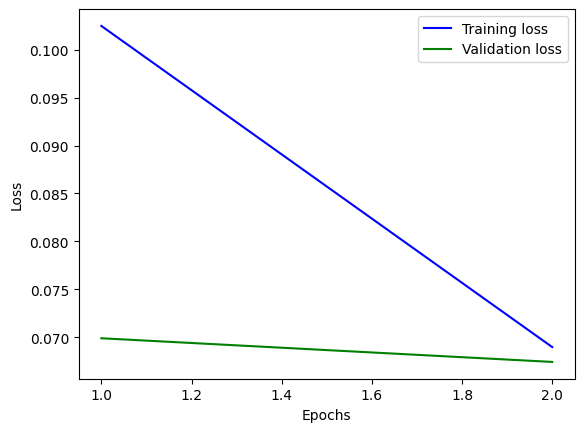

In [61]:
show_learning_curves(history_ae)

On teste le modÃ¨le sur 10 images alÃ©atoires...

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


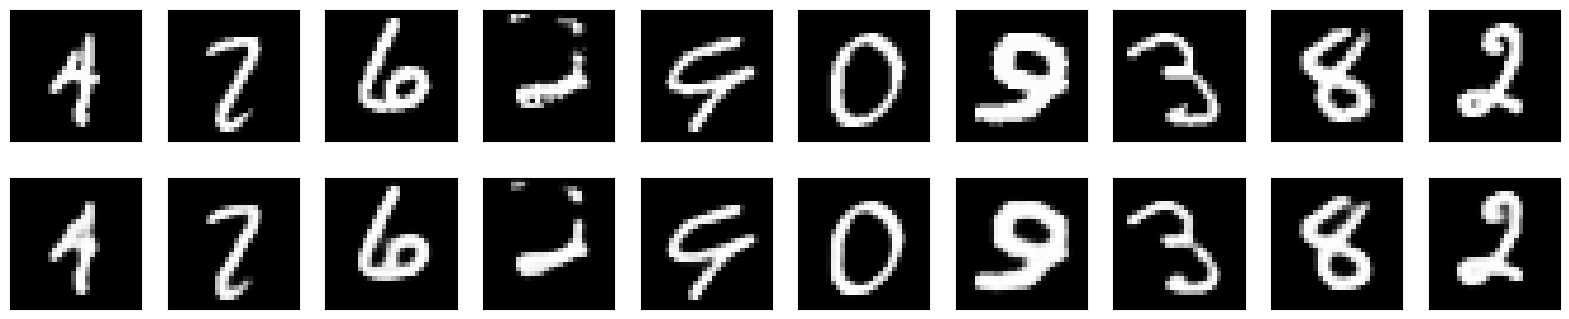

In [62]:
predictions = autoencoder.predict(test_data)
display(test_data, predictions,10)

## 3 - Application au dÃ©bruitage

### 3.1 - CrÃ©ation d'une version bruitÃ©e des images MNIST

Ajuster le niveau de bruit $\eta$ ($\eta \in ]0.0,1.0[$)

In [63]:
eta = 0.6
noisy_train_data = noise(train_data,eta)
noisy_test_data = noise(test_data,eta)

Affichage de quelques images alÃ©atoires et de leurs versions bruitÃ©es...

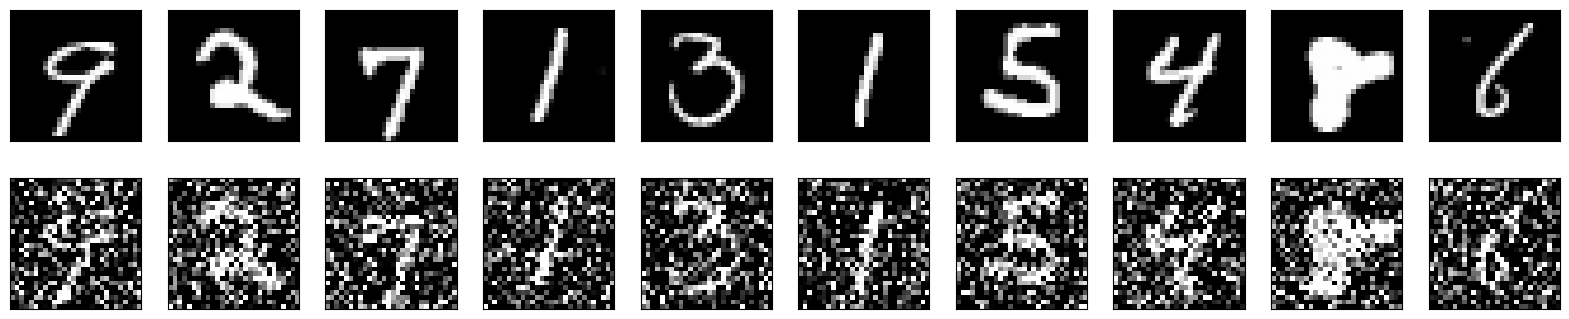

In [64]:
display(train_data, noisy_train_data, 10)

### 3.2 - RÃ©-entraÃ®nement du modÃ¨le pour dÃ©bruitage

A complÃ©ter ! Adapter les codes prÃ©cÃ©dents pour transformer votre autoencodeur en modÃ¨le de dÃ©bruitage, afficher les courbes d'apprentissage, quelques exemples d'images dÃ©bruitÃ©es, et calculer une mesure de performance sur l'ensemble de la base de test.

In [65]:
history_ae = autoencoder.fit(
    x=noisy_train_data,
    y=train_data,
    epochs=5,
    batch_size=64,
    shuffle=True,
    validation_data=(noisy_test_data, test_data))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 93ms/step - loss: 0.1287 - val_loss: 0.1207
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - loss: 0.1198 - val_loss: 0.1169
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 90s 96ms/step - loss: 0.1169 - val_loss: 0.1154
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 94s 101ms/step - loss: 0.1152 - val_loss: 0.1134
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 93s 99ms/step - loss: 0.1140 - val_loss: 0.1125


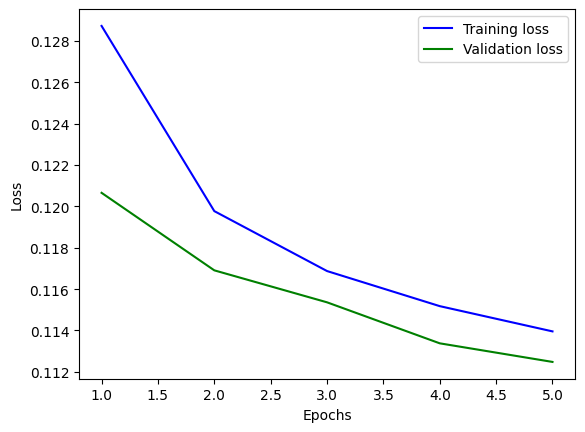

In [66]:
show_learning_curves(history_ae)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


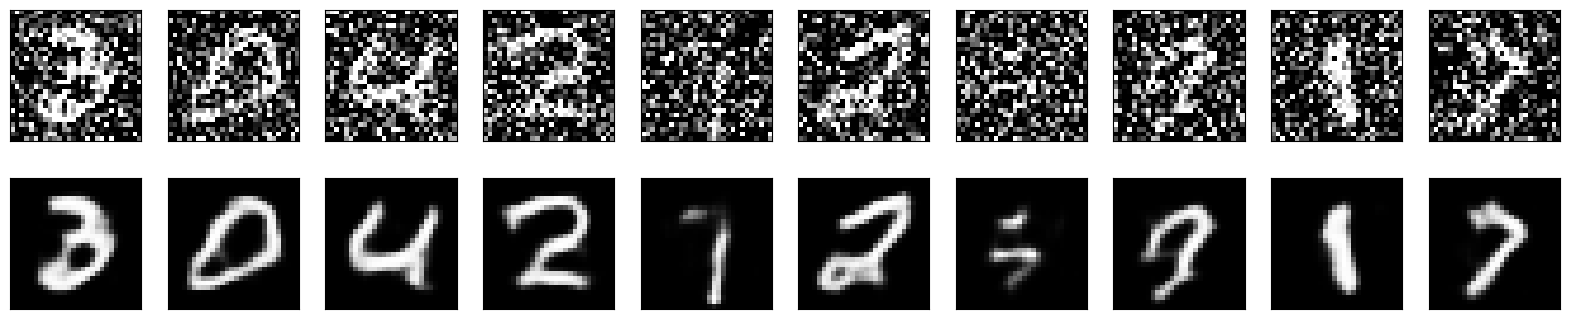

In [67]:
predictions = autoencoder.predict(noisy_test_data)
display(noisy_test_data, predictions,10)

### 3.3 - Application Ã  une image quelconque

A complÃ©ter ! Tester d'abord le modÃ¨le prÃ©cÃ©dent en zero-shot sur une image de grande taille de votre choix, puis Ã©laborer une stratÃ©gie pour rÃ©-entraÃ®ner le modÃ¨le spÃ©cifiquement pour cette image.

# With resizing

In [68]:
def show_img(img, title="Image"):
    if img.dtype == np.float64:
        img = img.astype(np.float32)
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

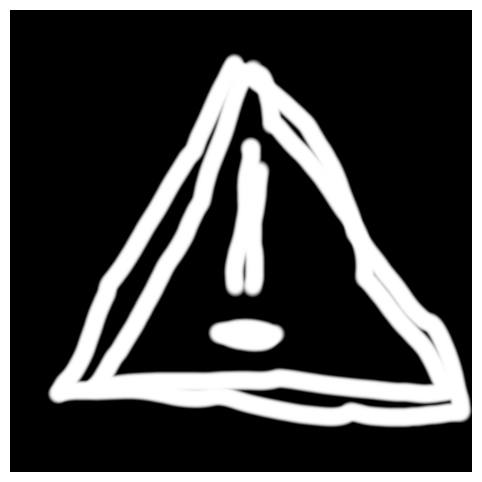

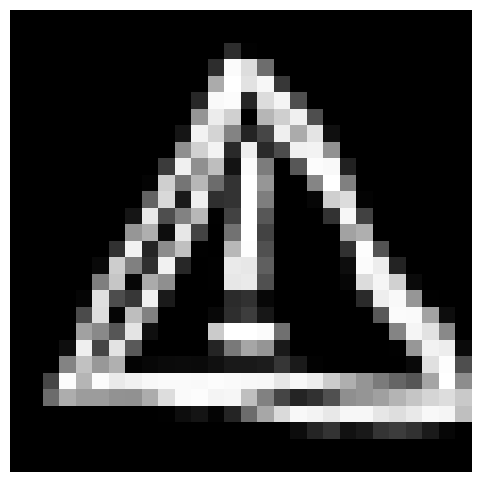

In [69]:
att = cv2.imread('attention.png')
att = cv2.cvtColor(att, cv2.COLOR_BGR2GRAY)
dimensions = (28, 28)
res_att = cv2.resize(att, dimensions, interpolation=cv2.INTER_AREA)
## to show the resized images
show_img(att,title="attention.png")
show_img(res_att,title="resized")

In [70]:
def process(image_name):
    img = cv2.imread(image_name)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img,dimensions,interpolation=cv2.INTER_AREA)
    return img

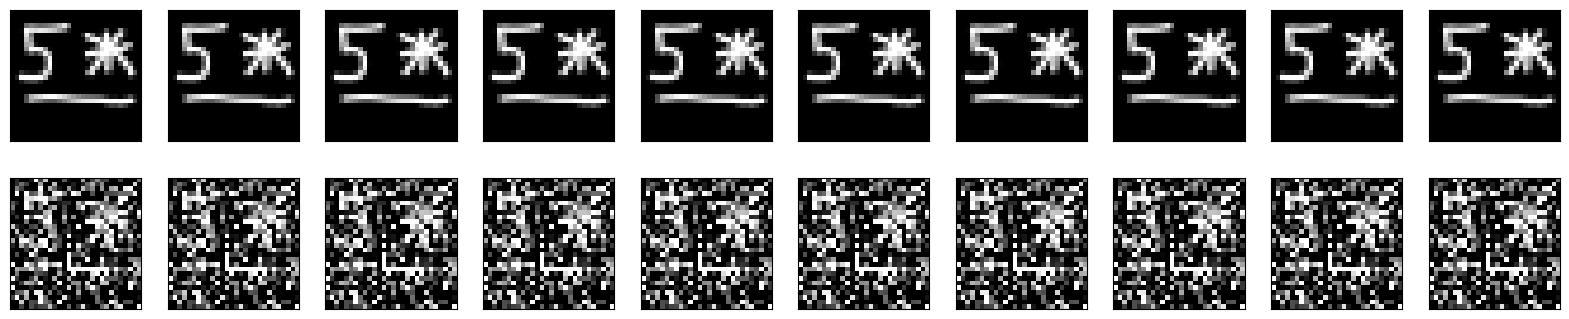

In [71]:
# image_names = ["attention.png","dollar.png","square.png","number_test.png"]
image_names = ["number_test.png"]
images = [process(image_names[i]) for i in range(len(image_names))]
my_images = preprocess(np.array(images))
noisy_images = noise(my_images,eta)
display(my_images, noisy_images, 10)

In [72]:
history_ae = autoencoder.fit(
    x=noisy_images,
    y=my_images,
    epochs=50,
    batch_size=64,
    shuffle=True,
    validation_data=(noisy_images, my_images))

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.3523 - val_loss: 0.2753
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2753 - val_loss: 0.2549
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.2549 - val_loss: 0.2256
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2256 - val_loss: 0.2343
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2343 - val_loss: 0.2277
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.2277 - val_loss: 0.2008
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 0.2008 - val_loss: 0.2001
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.2001 - val_loss: 0.1847
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1847 - val_loss: 0.1767
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.1767 - val_loss: 0.1797
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.1797 - val_loss: 0.1659
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.1659 - val_loss: 0.

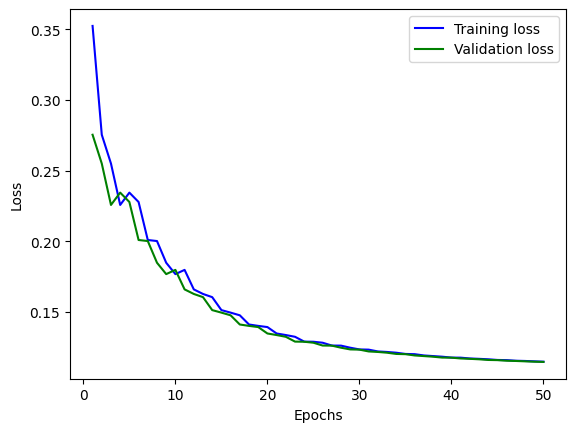

In [73]:
show_learning_curves(history_ae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


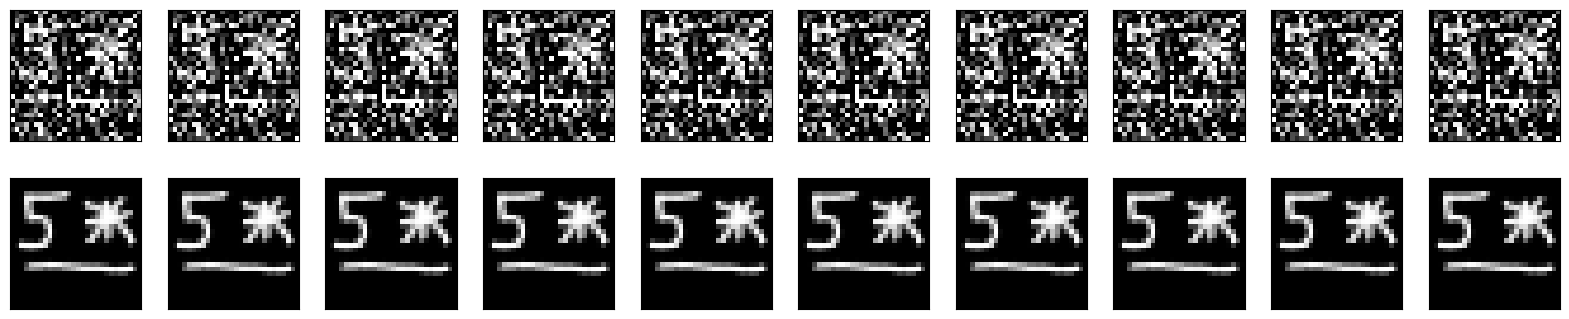

In [74]:
predictions = autoencoder.predict(noisy_images)
display(noisy_images, predictions,10)

In [75]:
bce = tf.keras.losses.BinaryCrossentropy()
loss = bce(my_images, predictions).numpy()
print(loss)

0.11455643


# with cutting

In [103]:
img = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE)
patch_size = 28
n_rows = img.shape[0] // patch_size
n_cols = img.shape[1] // patch_size

trimmed_img = img[:n_rows*patch_size, :n_cols*patch_size]
view = trimmed_img.reshape(n_rows, patch_size, n_cols, patch_size)
patches = view.transpose(0, 2, 1, 3).reshape(-1, patch_size, patch_size)
patches= preprocess(patches)
reconstructed_fast = patches.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
# show_img(reconstructed_fast,"lena")

Epoch 1/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.6932 - val_loss: 0.6931
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 0.6931 - val_loss: 0.6929
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 0.6929 - val_loss: 0.6928
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 0.6928 - val_loss: 0.6926
Epoch 5/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - loss: 0.6926 - val_loss: 0.6924
Epoch 6/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.6924 - val_loss: 0.6921
Epoch 7/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.6921 - val_loss: 0.6917
Epoch 8/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss: 0.6917 - val_loss: 0.6913
Epoch 9/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.6913 - val_loss: 0.6908
Epoch 10/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.6908 - val_loss: 0.6902
Epoch 11/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.6902 - val_loss: 0.6894
Epoch 12/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 0.6894 - val_loss: 0.6885
Epo

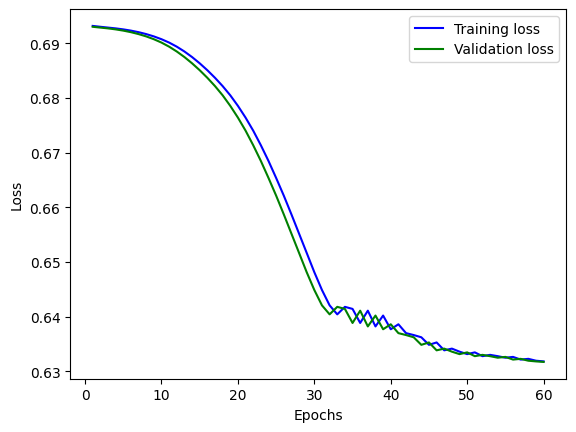

In [104]:
history_ae_flawed = autoencoder.fit(
    x=patches,
    y=patches,
    epochs=60,
    batch_size=64,
    shuffle=True,
    validation_data=(patches, patches))
show_learning_curves(history_ae_flawed)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


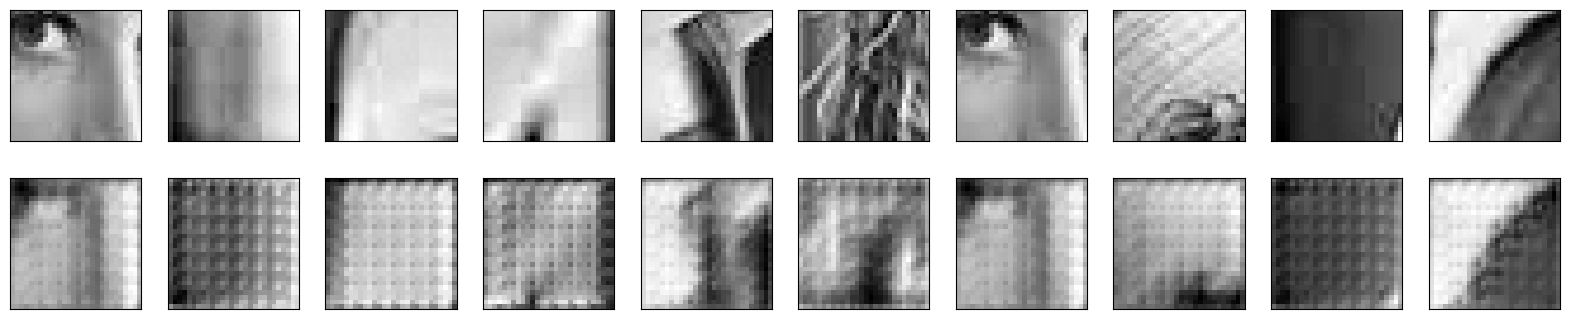

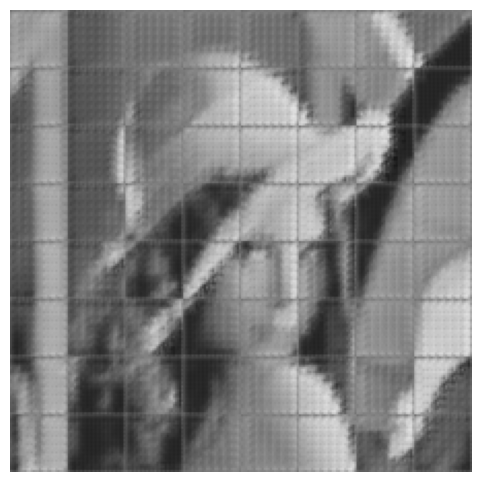

In [78]:
predictions = autoencoder.predict(patches)
display(patches,predictions,10)
pred_reconstruction = predictions.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
show_img(pred_reconstruction)

In [105]:
def get_patches(img, patch_size=28, offset=(0, 0)):
    off_y, off_x = offset
    cropped_img = img[off_y:, off_x:]
    
    n_rows = cropped_img.shape[0] // patch_size
    n_cols = cropped_img.shape[1] // patch_size
    
    trimmed_img = cropped_img[:n_rows * patch_size, :n_cols * patch_size]
    view = trimmed_img.reshape(n_rows, patch_size, n_cols, patch_size)
    patches = view.transpose(0, 2, 1, 3).reshape(-1, patch_size, patch_size)
    return patches

def reconstruct_patches(patches, n_rows, n_cols, patch_size=28):
    reconstructed = patches.reshape(n_rows, n_cols, patch_size, patch_size)
    reconstructed = reconstructed.transpose(0, 2, 1, 3)
    return reconstructed.reshape(n_rows * patch_size, n_cols * patch_size)


my_offsets = [(i,j) for j in range(28) for i in range(28)]
all_patch_batches = []
for offset in my_offsets:
    patches = get_patches(img, patch_size=28, offset=offset)
    all_patch_batches.append(patches)
train_data = np.concatenate(all_patch_batches, axis=0)
train_data = preprocess(train_data)

def half_patch_blend(img, autoencoder, patch_size=32):
    h, w = img.shape[:2]
    
    # --- IMAGE 1: No Offset (0,0) ---
    n_rows1 = h // patch_size
    n_cols1 = w // patch_size
    patches1 = get_patches(img, patch_size=patch_size, offset=(0, 0))
    
    # --- IMAGE 2: Half-Patch Offset (16,16) ---
    offset = patch_size // 2  # 16
    n_rows2 = (h - offset) // patch_size
    n_cols2 = (w - offset) // patch_size
    patches2 = get_patches(img, patch_size=patch_size, offset=(offset, offset))
    
    # Combine just these two groups into one quick batch
    all_patches = np.concatenate([patches1, patches2], axis=0)
    processed = preprocess(all_patches, patch_size=patch_size)
    
    # One fast prediction call
    predictions = autoencoder.predict(processed, verbose=0)
    predictions = np.squeeze(predictions, axis=-1) # Drop channel dim
    
    # Split the predictions back into their respective groups
    preds1 = predictions[:len(patches1)]
    preds2 = predictions[len(patches1):]
    
    # Reconstruct both images using your fast numpy logic
    recon1 = reconstruct_patches(preds1, n_rows1, n_cols1, patch_size=patch_size)
    recon2 = reconstruct_patches(preds2, n_rows2, n_cols2, patch_size=patch_size)
    
    # --- Blending Canvas ---
    # Create empty canvases to hold the sum and a count map for averaging
    canvas = np.zeros((h, w), dtype=np.float32)
    counts = np.zeros((h, w), dtype=np.float32)
    
    # Paste the first reconstruction (0,0)
    canvas[:n_rows1*patch_size, :n_cols1*patch_size] += recon1
    counts[:n_rows1*patch_size, :n_cols1*patch_size] += 1.0
    
    # Paste the second reconstruction shifted by (16,16)
    canvas[offset:offset+n_rows2*patch_size, offset:offset+n_cols2*patch_size] += recon2
    counts[offset:offset+n_rows2*patch_size, offset:offset+n_cols2*patch_size] += 1.0
    
    # Average the overlapping areas to dissolve the grid lines
    counts[counts == 0] = 1.0
    final_img = canvas / counts
    
    return final_img

In [106]:
history_ae = autoencoder.fit(
    x=train_data,
    y=train_data,
    epochs=5,
    batch_size=64,
    shuffle=True,
    validation_data=(train_data, train_data))

Epoch 1/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 67s 109ms/step - loss: 0.6225 - val_loss: 0.6208
Epoch 2/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 69s 112ms/step - loss: 0.6202 - val_loss: 0.6199
Epoch 3/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 67s 109ms/step - loss: 0.6195 - val_loss: 0.6193
Epoch 4/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 87s 117ms/step - loss: 0.6191 - val_loss: 0.6190
Epoch 5/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 65s 107ms/step - loss: 0.6188 - val_loss: 0.6187


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


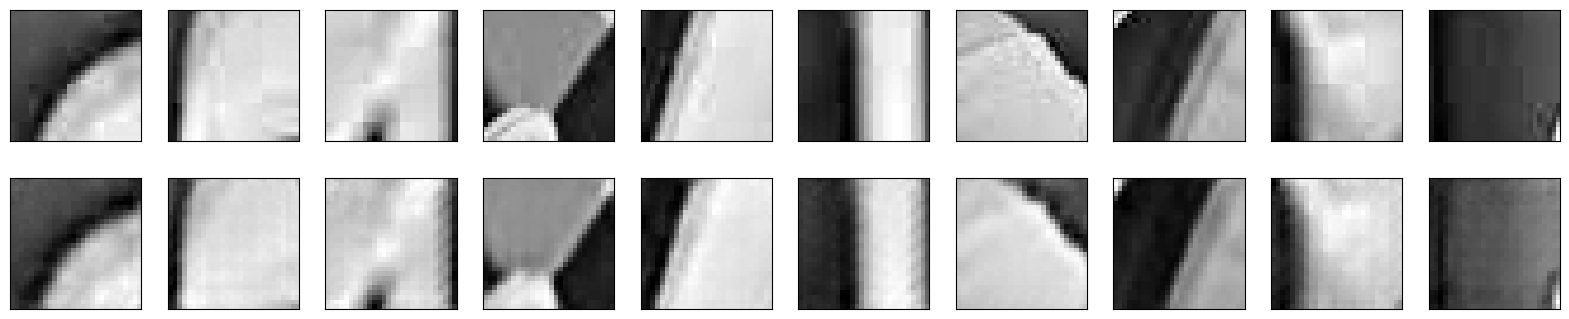

In [81]:
patches = preprocess(np.array(get_patches(img,patch_size=28)))
predictions = autoencoder.predict(patches)
display(patches,predictions,10)

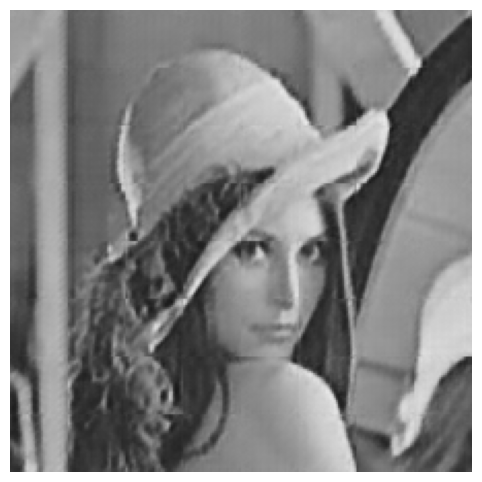

(225, 225)


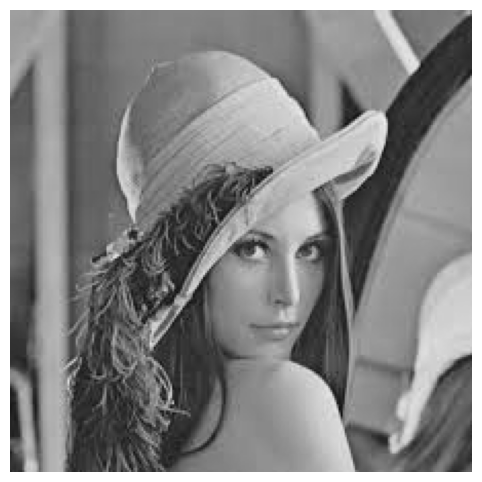

In [82]:
pred_reconstruction = predictions.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
show_img(pred_reconstruction)
print(np.shape(img))
show_img(img)

In [107]:
train_x = noise(train_data,0.1)
history_ae = autoencoder.fit(
    x=train_x,
    y=train_data,
    epochs=5,
    batch_size=64,
    shuffle=True,
    validation_data=(train_x, train_data))

Epoch 1/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - loss: 0.6212 - val_loss: 0.6209
Epoch 2/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 69s 113ms/step - loss: 0.6208 - val_loss: 0.6207
Epoch 3/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 89s 124ms/step - loss: 0.6206 - val_loss: 0.6205
Epoch 4/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 70s 115ms/step - loss: 0.6205 - val_loss: 0.6204
Epoch 5/5
613/613 ━━━━━━━━━━━━━━━━━━━━ 71s 115ms/step - loss: 0.6204 - val_loss: 0.6203


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step 


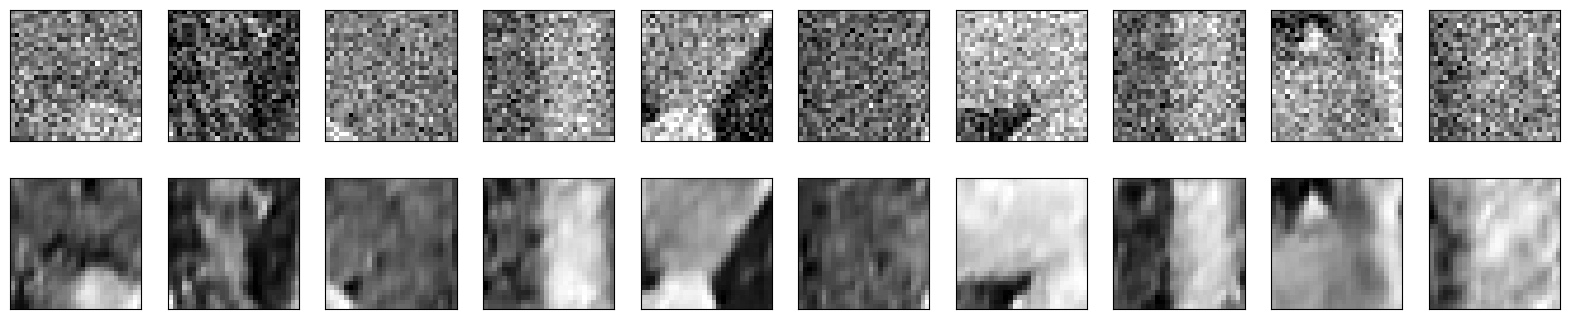

In [108]:
patches = preprocess(np.array(get_patches(img,patch_size=28)))
patches = noise(patches,0.15)
predictions = autoencoder.predict(patches)
display(patches,predictions,10)

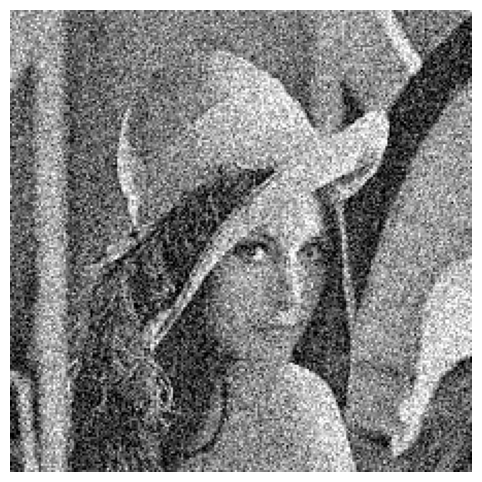

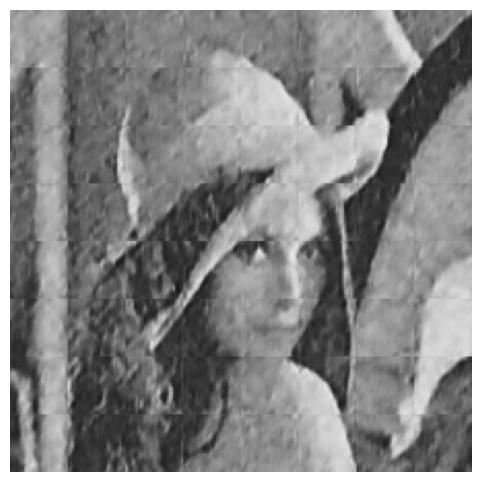

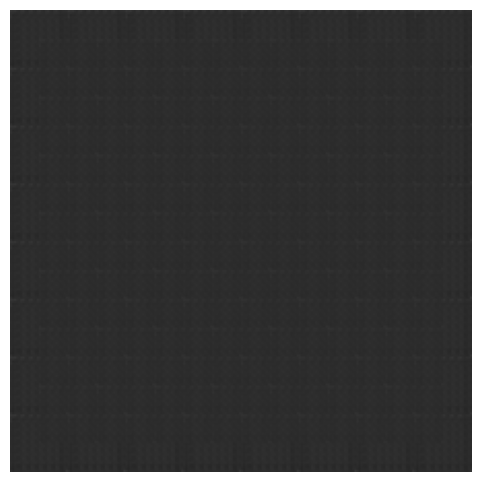

In [109]:
reconstructed_fast = patches.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
pred_reconstruction = predictions.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
show_img(reconstructed_fast)
show_img(pred_reconstruction)
show_img(half_patch_blend(reconstructed_fast,autoencoder,patch_size=28))

167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


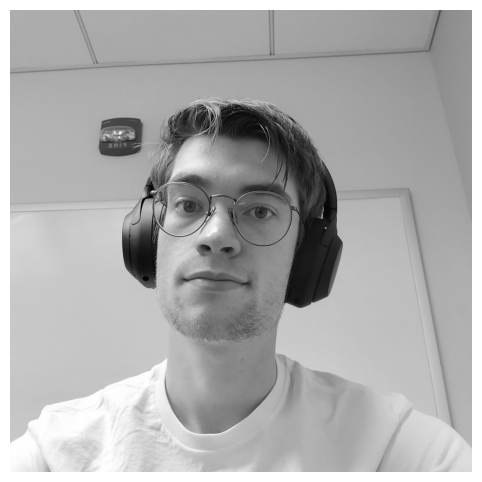

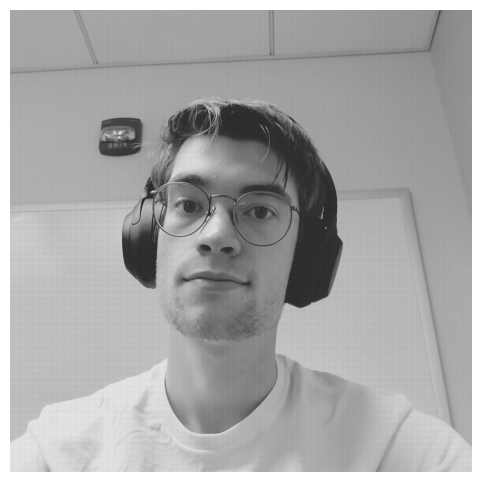

In [86]:
img = cv2.imread('me.jpeg', cv2.IMREAD_GRAYSCALE)
patch_size = 28
n_rows = img.shape[0] // patch_size
n_cols = img.shape[1] // patch_size
patches = preprocess(np.array(get_patches(img,patch_size=28)))
reconstructed_fast = patches.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
predictions = autoencoder.predict(patches)
pred_reconstruction = predictions.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
show_img(reconstructed_fast)
show_img(pred_reconstruction)

In [87]:
input = layers.Input(shape=(32, 32, 1))
"""Encodeur"""
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
"""DÃ©codeur"""
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)
"""Auto-encodeur"""
autoencoder = Model(input, x)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 8, 8, 32)       │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 16, 16, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 32, 32, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 46,849 (183.00 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
img = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE)
patch_size = 32
n_rows = img.shape[0] // patch_size
n_cols = img.shape[1] // patch_size
my_offsets = [(i,j) for j in range(32) for i in range(32)]
all_patch_batches = []
for offset in my_offsets:
    patches = get_patches(img, patch_size=32, offset=offset)
    all_patch_batches.append(patches)
train_data = np.concatenate(all_patch_batches, axis=0)
train_data = preprocess(train_data,patch_size=32)

In [89]:
train_data = train_data.astype("float32")
train_x = noise(train_data, 0.05)
train_x = train_x.astype("float32")

print(f"train_x: {train_x.shape}, dtype: {train_x.dtype}")
print(f"train_data: {train_data.shape}, dtype: {train_data.dtype}")

history_ae = autoencoder.fit(
    x=train_x,
    y=train_data,
    epochs=5,
    batch_size=64,
    shuffle=True,
    validation_data=(train_x, train_data))

train_x: (37636, 32, 32, 1), dtype: float32
train_data: (37636, 32, 32, 1), dtype: float32
Epoch 1/5
589/589 ━━━━━━━━━━━━━━━━━━━━ 95s 158ms/step - loss: 0.6319 - val_loss: 0.6246
Epoch 2/5
589/589 ━━━━━━━━━━━━━━━━━━━━ 100s 169ms/step - loss: 0.6238 - val_loss: 0.6234
Epoch 3/5
589/589 ━━━━━━━━━━━━━━━━━━━━ 92s 157ms/step - loss: 0.6228 - val_loss: 0.6225
Epoch 4/5
589/589 ━━━━━━━━━━━━━━━━━━━━ 97s 165ms/step - loss: 0.6222 - val_loss: 0.6223
Epoch 5/5
589/589 ━━━━━━━━━━━━━━━━━━━━ 132s 148ms/step - loss: 0.6218 - val_loss: 0.6216


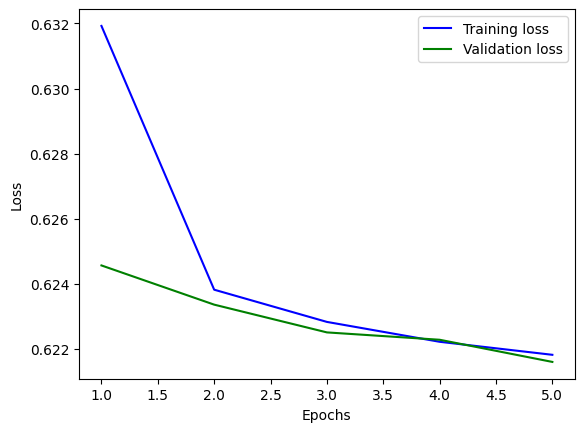

In [90]:
show_learning_curves(history_ae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


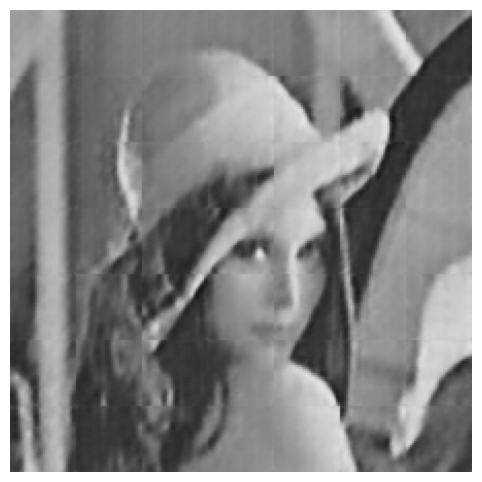

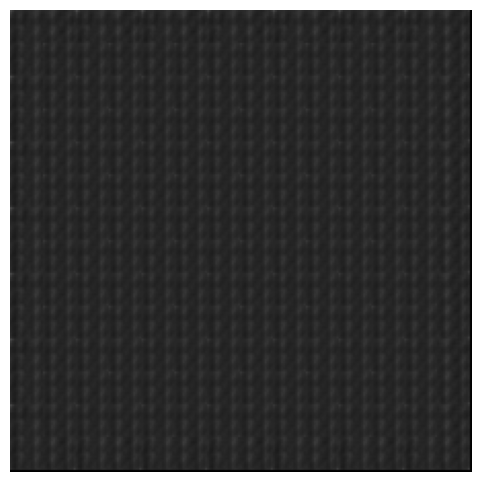

In [91]:
patches = preprocess(np.array(get_patches(img, patch_size=32)), patch_size=32)
predictions = autoencoder.predict(patches)
pred_reconstruction = predictions.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
show_img(pred_reconstruction)
show_img(half_patch_blend(noise(img,0.02),autoencoder))

128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


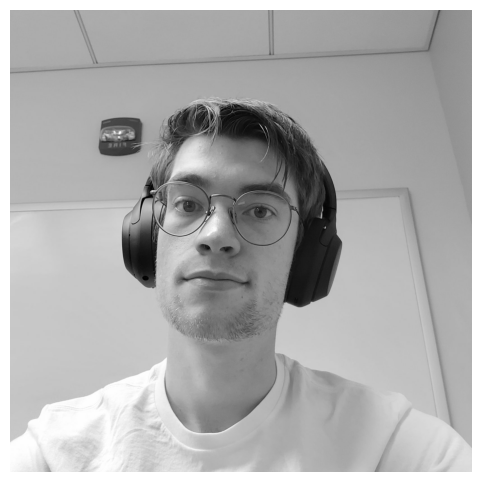

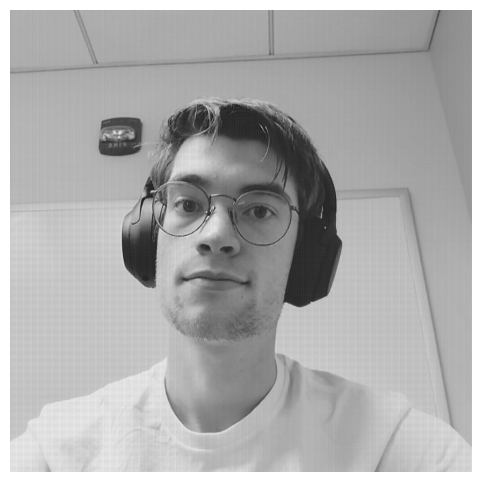

In [92]:
img = cv2.imread('me.jpeg', cv2.IMREAD_GRAYSCALE)
patch_size = 32
n_rows = img.shape[0] // patch_size
n_cols = img.shape[1] // patch_size
patches = preprocess(np.array(get_patches(img,patch_size=32)),patch_size=32)
reconstructed_fast = patches.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
predictions = autoencoder.predict(patches)
pred_reconstruction = predictions.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
show_img(reconstructed_fast)
show_img(pred_reconstruction)

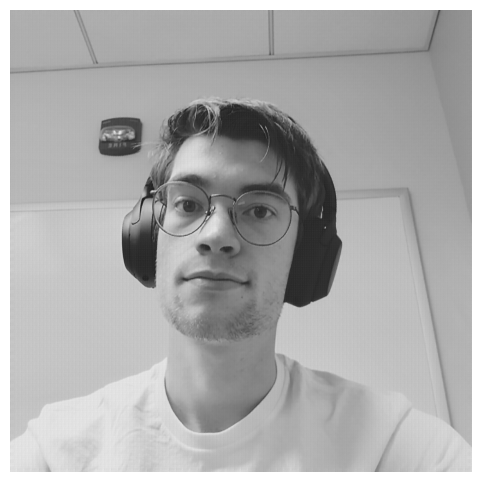

In [93]:
show_img(half_patch_blend(img,autoencoder))

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


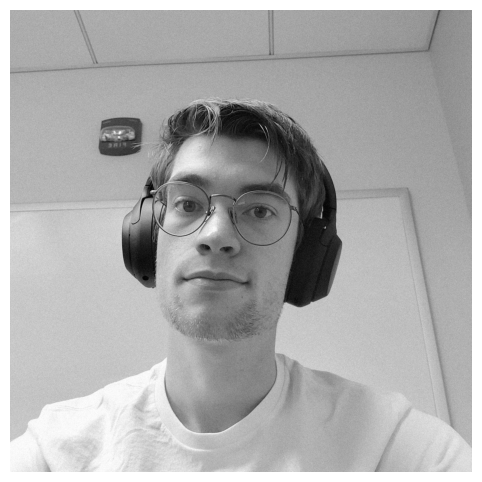

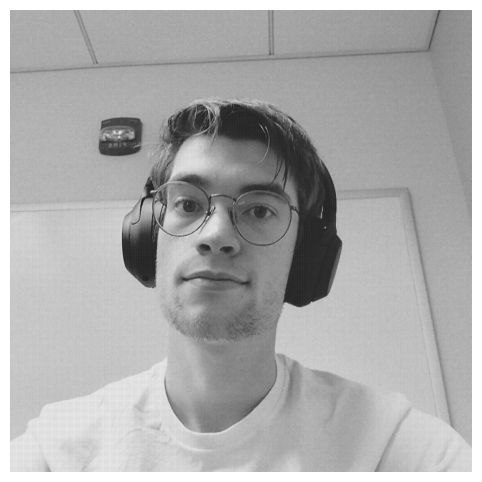

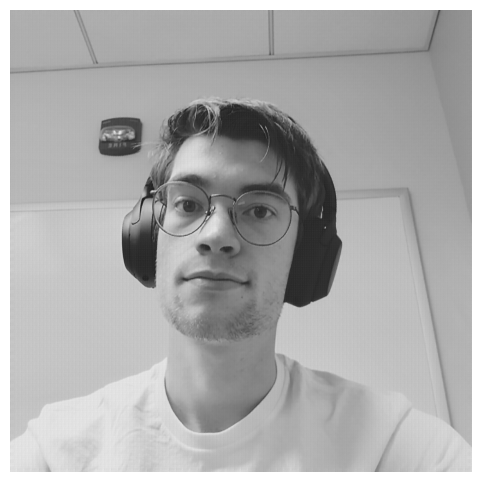

In [94]:
patches = preprocess(np.array(get_patches(img,patch_size=32)),patch_size=32)
patches = noise(patches,0.05)
reconstructed_fast = patches.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
predictions = autoencoder.predict(patches)
pred_reconstruction = predictions.reshape(n_rows, n_cols, patch_size, patch_size).transpose(0, 2, 1, 3).reshape(n_rows*patch_size, n_cols*patch_size)
show_img(reconstructed_fast)
show_img(pred_reconstruction)
show_img(half_patch_blend(img,autoencoder))